# K-Means Clustering Kost (k=5)

Segmentasi: Ekonomis / Terjangkau / Menengah / Standar Atas / Premium

Mapping nilai:
- tipe_kos: 1=Pria, 2=Wanita, 3=Campur
- kelas: 1=Ekonomi, 2=Standar, 3=Premium
- fasilitas: 1=Ada, 0=Tidak Ada
- k_mandi: 0=luar, 1=dalam

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

## 2. Load Data

In [2]:
FILE_PATH = 'dataset_kost_final_300_revisi.xlsx'

df_raw = pd.read_excel(FILE_PATH)
print(f'Jumlah baris  : {df_raw.shape[0]}')
print(f'Jumlah kolom  : {df_raw.shape[1]}')
df_raw.head()

Jumlah baris  : 300
Jumlah kolom  : 18


,nama tempat,wilayah,kode lokasi,lokasi,ukuran kamar,kelas,listrik,AC,K. Mandi,Parkir Motor,Laundry,Wifi,Price,tipe_kos,status,Foto,Alamat,No.Telepon
0,Kost Singgahsini Barada Cipondoh Tipe C Tangerang,Tangerang,8,Cipondoh,28,3,0,1,1,1,0,1,1948750,3,1,https://static.mamikos.com/uploads/cache/data/...,"Jl. Raya Dongkal, RT.006/RW.005, Cipondoh Makm...",8.131246e+10
1,Kost Permata Tipe T Plus Cipondoh Tangerang,Tangerang,8,Cipondoh,10,1,0,0,1,1,1,1,1507500,1,1,https://static.mamikos.com/uploads/cache/data/...,"Jl. KH. Ahmad Dahlan, RT.005/RW.008, Petir, Ke...",8.217634e+10
2,Kost Singgahsini Waru 15A Tipe A Pasar Rebo Ja...,Jakarta Timur,10,Mampang Prapatan,9,1,0,1,1,1,0,1,1497000,2,2,https://i.ytimg.com/vi/8alNpTDVeBg/maxresdefau...,"Jl. Waru / Gang Waru No.15A, Kecamatan Pasar R...",8.571235e+10
3,Kost Bu Sri Tipe D Babakan Madang Bogor,Bogor,6,Babakan Madang,9,1,1,1,1,0,0,1,1800000,3,0,https://static.mamikos.com/uploads/cache/data/...,"Jl. Alam Segar No.15, sentul city, Kec. Babaka...",8.782356e+10
4,Kost Pak Yanto Tipe A Cibitung Bekasi,Bekasi,9,Cibitung,12,2,0,0,1,1,0,1,650000,1,2,https://static.mamikos.com/uploads/cache/data/...,"Jl. Jawa No.8-9, Cibuntu, Kec. Cibitung, Kabup...",8.139875e+10


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   nama tempat   300 non-null    object 
 1   wilayah       300 non-null    object 
 2   kode lokasi   300 non-null    int64  
 3   lokasi        300 non-null    object 
 4   ukuran kamar  300 non-null    int64  
 5   kelas         300 non-null    int64  
 6   listrik       300 non-null    int64  
 7   AC            300 non-null    int64  
 8   K. Mandi      300 non-null    int64  
 9   Parkir Motor  300 non-null    int64  
 10  Laundry       300 non-null    int64  
 11  Wifi          300 non-null    int64  
 12  Price         300 non-null    int64  
 13  tipe_kos      300 non-null    int64  
 14  status        300 non-null    int64  
 15  Foto          19 non-null     object 
 16  Alamat        19 non-null     object 
 17  No.Telepon    19 non-null     float64
dtypes: float64(1), int64(12), obje

In [4]:
df_raw.describe()

,kode lokasi,ukuran kamar,kelas,listrik,AC,K. Mandi,Parkir Motor,Laundry,Wifi,Price,tipe_kos,status,No.Telepon
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,3.000000e+02,300.000000,300.000000,1.900000e+01
mean,6.803333,10.816667,1.453333,0.236667,0.743333,0.740000,0.943333,0.186667,0.890000,1.625039e+06,2.436667,0.933333,8.417823e+10
std,3.049972,4.781835,0.612977,0.425746,0.437524,0.439367,0.231591,0.390295,0.313413,7.203620e+05,0.703067,0.893430,2.768234e+09
min,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000e+05,1.000000,0.000000,8.131246e+10
25%,4.000000,9.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.165000e+06,2.000000,0.000000,8.160253e+10
50%,8.000000,9.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.500000e+06,3.000000,1.000000,8.219877e+10
75%,10.000000,12.000000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,2.000000e+06,3.000000,1.000000,8.678423e+10
max,10.000000,30.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.500000e+06,3.000000,3.000000,8.785673e+10


## 3. Preprocessing

### 3.1 Seleksi Fitur

In [5]:
FEATURE_COLS = [
    'kode lokasi',
    'ukuran kamar',
    'kelas',
    'listrik',
    'AC',
    'K. Mandi',
    'Parkir Motor',
    'Laundry',
    'Wifi',
    'tipe_kos',
    'Price'
]

INFO_COLS = ['nama tempat', 'wilayah', 'lokasi', 'Alamat']

df = df_raw[FEATURE_COLS + INFO_COLS].copy()
df.columns = [
    'kode_lokasi', 'ukuran_kamar', 'kelas', 'listrik', 'ac',
    'k_mandi', 'parkir_motor', 'laundry', 'wifi', 'tipe_kos',
    'price', 'nama', 'wilayah', 'lokasi', 'alamat'
]

print(f'Shape setelah seleksi fitur: {df.shape}')

Shape setelah seleksi fitur: (300, 15)


### 3.2 Handling Missing Values

In [6]:
print('Missing values per kolom:')
print(df.isnull().sum())

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'\nData setelah dropna: {len(df)} baris')

Missing values per kolom:
kode_lokasi       0
ukuran_kamar      0
kelas             0
listrik           0
ac                0
k_mandi           0
parkir_motor      0
laundry           0
wifi              0
tipe_kos          0
price             0
nama              0
wilayah           0
lokasi            0
alamat          281
dtype: int64

Data setelah dropna: 19 baris


### 3.3 Handling Outlier dengan IQR

Q1    : Rp 1,050,000
Q3    : Rp 1,791,250
IQR   : Rp 741,250
Lower : Rp -61,875
Upper : Rp 2,903,125
Outlier ditemukan: 0 baris


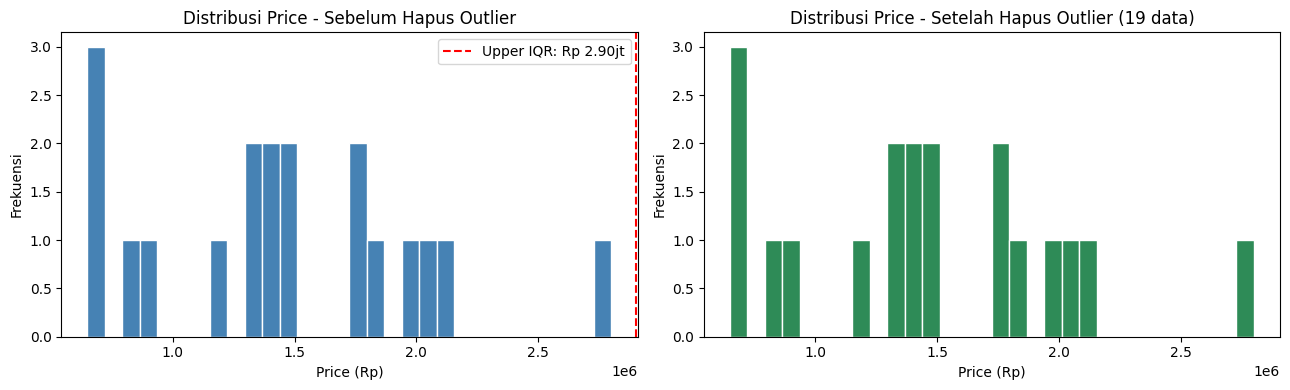

Data akhir siap clustering: 19 baris


In [7]:
Q1  = df['price'].quantile(0.25)
Q3  = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_mask = (df['price'] < lower) | (df['price'] > upper)
print(f'Q1    : Rp {Q1:,.0f}')
print(f'Q3    : Rp {Q3:,.0f}')
print(f'IQR   : Rp {IQR:,.0f}')
print(f'Lower : Rp {lower:,.0f}')
print(f'Upper : Rp {upper:,.0f}')
print(f'Outlier ditemukan: {outlier_mask.sum()} baris')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['price'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(upper, color='red', linestyle='--', linewidth=1.5, label=f'Upper IQR: Rp {upper/1e6:.2f}jt')
axes[0].set_title('Distribusi Price - Sebelum Hapus Outlier')
axes[0].set_xlabel('Price (Rp)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

df = df[~outlier_mask].copy()
df.reset_index(drop=True, inplace=True)

axes[1].hist(df['price'], bins=30, color='seagreen', edgecolor='white')
axes[1].set_title(f'Distribusi Price - Setelah Hapus Outlier ({len(df)} data)')
axes[1].set_xlabel('Price (Rp)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

print(f'Data akhir siap clustering: {len(df)} baris')

### 3.4 Distribusi Seluruh Fitur

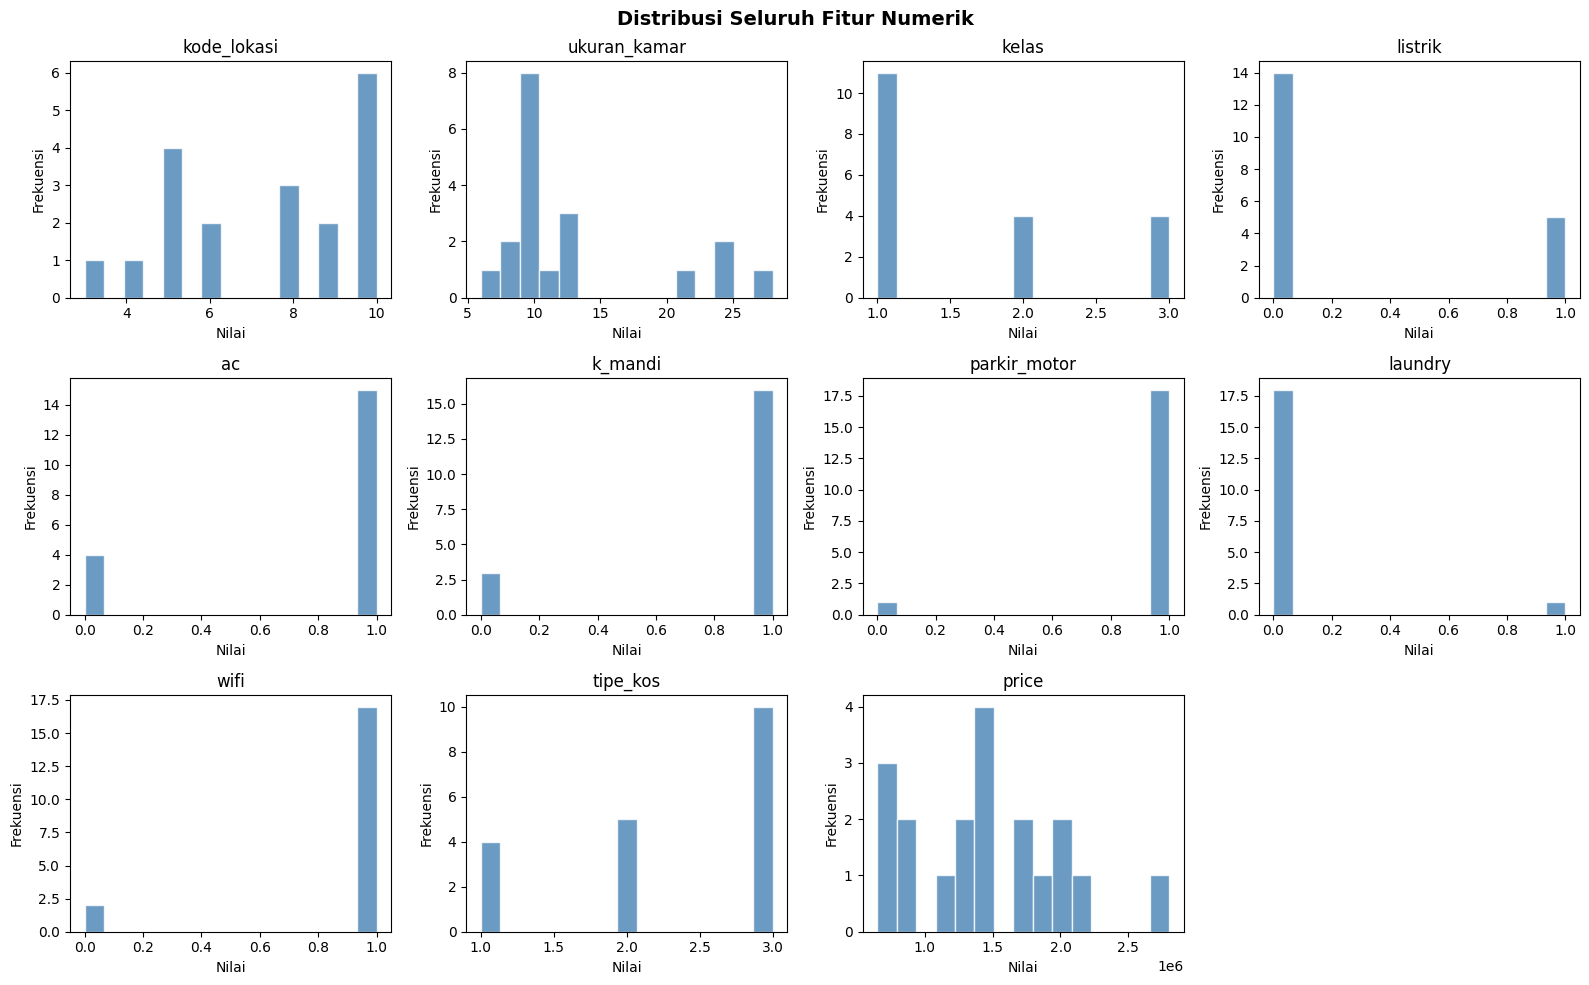

In [8]:
NUMERIC_FEATS = [
    'kode_lokasi', 'ukuran_kamar', 'kelas', 'listrik', 'ac',
    'k_mandi', 'parkir_motor', 'laundry', 'wifi', 'tipe_kos', 'price'
]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(NUMERIC_FEATS):
    axes[i].hist(df[col], bins=15, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')
for j in range(len(NUMERIC_FEATS), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribusi Seluruh Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 Heatmap Korelasi

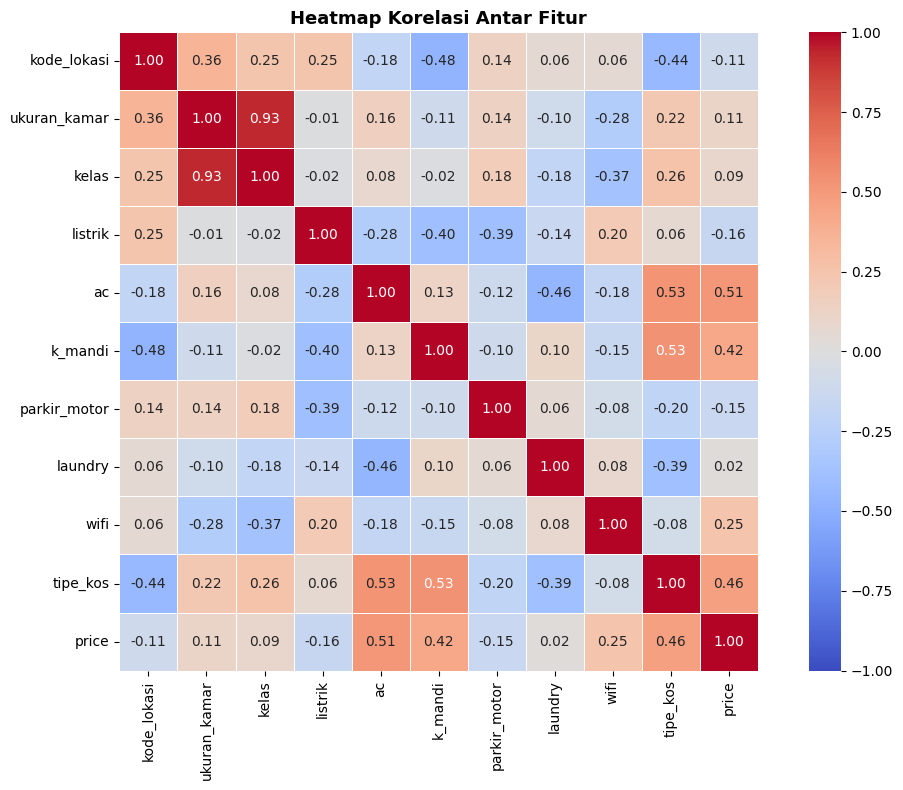

In [9]:
plt.figure(figsize=(11, 8))
corr = df[NUMERIC_FEATS].corr()
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=0.5,
    vmin=-1,
    vmax=1
)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.6 StandardScaler

In [10]:
X = df[NUMERIC_FEATS].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('StandardScaler selesai')
print(f'Mean price sebelum scaling : {df["price"].mean():>15,.2f}')
print(f'Std  price sebelum scaling : {df["price"].std():>15,.2f}')
print(f'Mean price setelah scaling : {X_scaled[:, -1].mean():>15.4f}')
print(f'Std  price setelah scaling : {X_scaled[:, -1].std():>15.4f}')

df_scaled_preview = pd.DataFrame(X_scaled, columns=NUMERIC_FEATS)
df_scaled_preview.head()

StandardScaler selesai
Mean price sebelum scaling :    1,457,628.95
Std  price sebelum scaling :      569,691.86
Mean price setelah scaling :         -0.0000
Std  price setelah scaling :          1.0000


,kode_lokasi,ukuran_kamar,kelas,listrik,ac,k_mandi,parkir_motor,laundry,wifi,tipe_kos,price
0,0.246709,2.367524,1.692456,-0.597614,0.516398,0.433013,0.235702,-0.235702,0.342997,0.857195,0.885705
1,0.246709,-0.424522,-0.781133,-0.597614,-1.936492,0.433013,0.235702,4.242641,0.342997,-1.648451,0.089939
2,1.098975,-0.579635,-0.781133,-0.597614,0.516398,0.433013,0.235702,-0.235702,0.342997,-0.395628,0.071003
3,-0.605558,-0.579635,-0.781133,1.673320,0.516398,0.433013,-4.242641,-0.235702,0.342997,0.857195,0.617444
4,0.672842,-0.114294,0.455661,-0.597614,-1.936492,0.433013,0.235702,-0.235702,0.342997,-1.648451,-1.456506


### 3.7 Boxplot Sebelum dan Sesudah Scaling

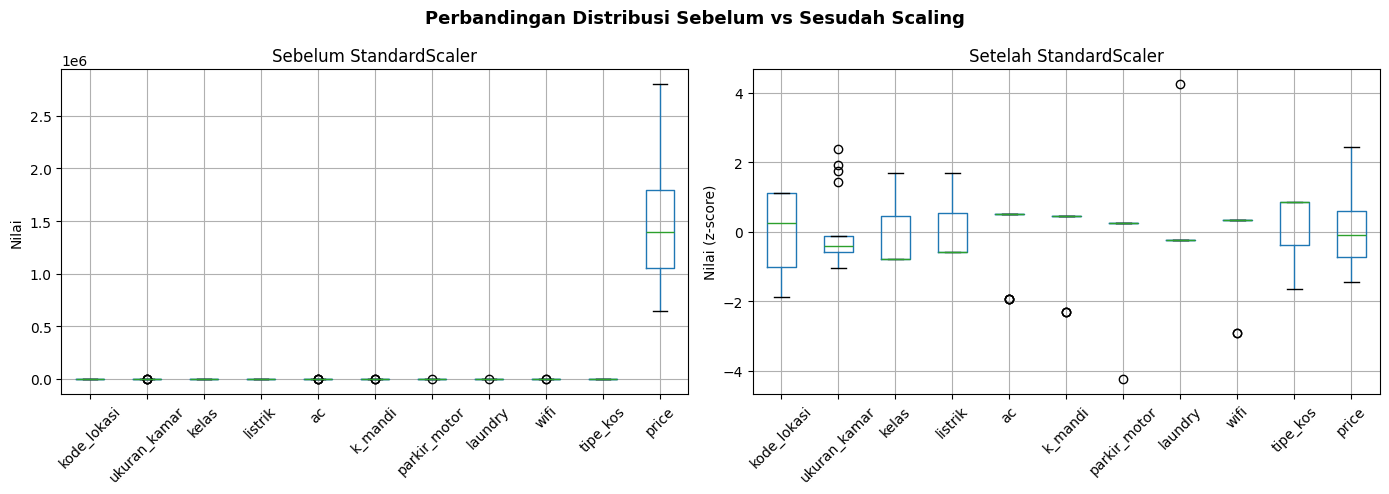

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[NUMERIC_FEATS].boxplot(ax=axes[0], rot=45)
axes[0].set_title('Sebelum StandardScaler')
axes[0].set_ylabel('Nilai')

df_scaled_preview.boxplot(ax=axes[1], rot=45)
axes[1].set_title('Setelah StandardScaler')
axes[1].set_ylabel('Nilai (z-score)')

plt.suptitle('Perbandingan Distribusi Sebelum vs Sesudah Scaling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Modelling K-Means

### 4.1 Elbow Method

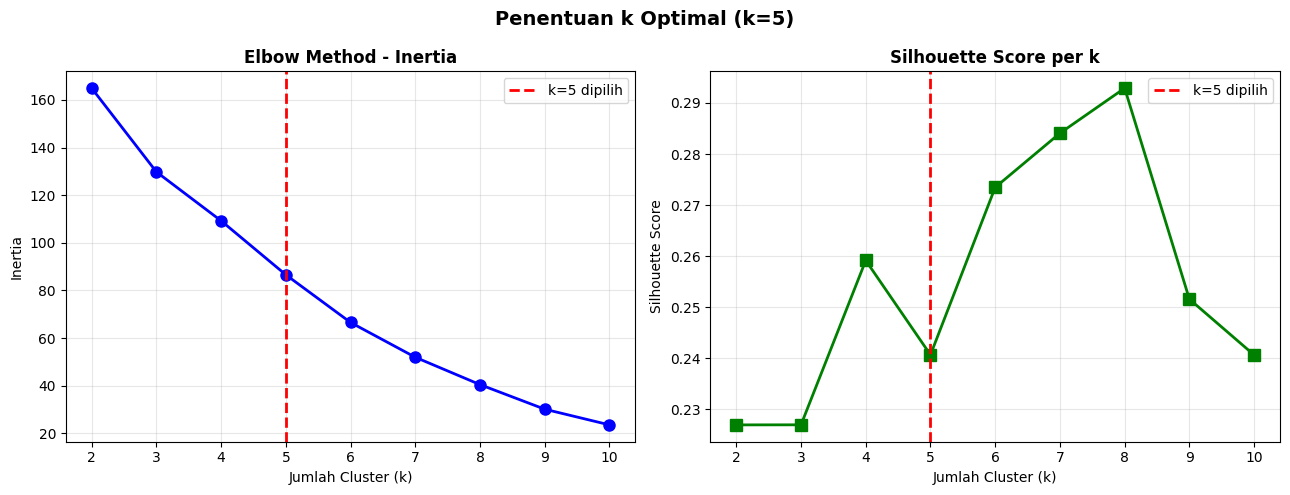

Silhouette Score per k:
  k=2: 0.2270
  k=3: 0.2270
  k=4: 0.2592
  k=5: 0.2407 <- DIPILIH
  k=6: 0.2735
  k=7: 0.2841
  k=8: 0.2929
  k=9: 0.2516
  k=10: 0.2406


In [13]:
inertias    = []
silhouettes = []
K_RANGE     = range(2, 11)

for k in K_RANGE:
    km     = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(K_RANGE), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=5, color='red', linestyle='--', linewidth=2, label='k=5 dipilih')
axes[0].set_title('Elbow Method - Inertia', fontweight='bold')
axes[0].set_xlabel('Jumlah Cluster (k)')
axes[0].set_ylabel('Inertia')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(list(K_RANGE), silhouettes, 'gs-', linewidth=2, markersize=8)
axes[1].axvline(x=5, color='red', linestyle='--', linewidth=2, label='k=5 dipilih')
axes[1].set_title('Silhouette Score per k', fontweight='bold')
axes[1].set_xlabel('Jumlah Cluster (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Penentuan k Optimal (k=5)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Silhouette Score per k:')
for k, s in zip(K_RANGE, silhouettes):
    tanda = ' <- DIPILIH' if k == 5 else ''
    print(f'  k={k}: {s:.4f}{tanda}')

### 4.2 Training K-Means k=5

In [14]:
K_OPTIMAL = 5

kmeans = KMeans(
    n_clusters=K_OPTIMAL,
    init='k-means++',
    max_iter=300,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)
df['cluster'] = kmeans.labels_

print(f'K-Means (k={K_OPTIMAL}) selesai dilatih')
print(f'Inertia akhir : {kmeans.inertia_:.2f}')
print(f'Iterasi       : {kmeans.n_iter_}')
print()
print('Distribusi data per cluster:')
print(df['cluster'].value_counts().sort_index())

K-Means (k=5) selesai dilatih
Inertia akhir : 86.58
Iterasi       : 2

Distribusi data per cluster:
cluster
0    10
1     4
2     3
3     1
4     1
Name: count, dtype: int64


In [15]:
cluster_stats = df.groupby('cluster').agg(
    price_mean = ('price', 'mean'),
    price_min  = ('price', 'min'),
    price_max  = ('price', 'max'),
    jumlah     = ('price', 'count'),
    kelas_mean = ('kelas', 'mean'),
    ac_pct     = ('ac',   lambda x: f"{x.mean()*100:.0f}%"),
    wifi_pct   = ('wifi', lambda x: f"{x.mean()*100:.0f}%")
).sort_values('price_mean').reset_index()

segmen_labels = ['Ekonomis', 'Terjangkau', 'Menengah', 'Standar Atas', 'Premium']
cluster_stats['segmen'] = segmen_labels

cluster_to_segmen = dict(zip(cluster_stats['cluster'], cluster_stats['segmen']))
df['segmen'] = df['cluster'].map(cluster_to_segmen)

print('Profil Cluster:')
print(cluster_stats[['cluster', 'segmen', 'price_mean', 'price_min', 'price_max', 'jumlah', 'ac_pct', 'wifi_pct']].to_string(index=False))

Profil Cluster:
 cluster       segmen   price_mean  price_min  price_max  jumlah ac_pct wifi_pct
       2     Ekonomis 7.333333e+05     650000     900000       3    33%     100%
       4   Terjangkau 1.507500e+06    1507500    1507500       1     0%     100%
       0     Menengah 1.553870e+06     820000    2095000      10    90%      90%
       1 Standar Atas 1.662188e+06     700000    2800000       4   100%      75%
       3      Premium 1.800000e+06    1800000    1800000       1   100%     100%


## 5. Evaluasi Model

### 5.1 Metrik Evaluasi

In [16]:
sil = silhouette_score(X_scaled, kmeans.labels_)
db  = davies_bouldin_score(X_scaled, kmeans.labels_)
ch  = calinski_harabasz_score(X_scaled, kmeans.labels_)

print('=' * 50)
print(f'  EVALUASI K-MEANS  (k={K_OPTIMAL})')
print('=' * 50)
print(f'  Silhouette Score     : {sil:.4f}   (max=1.0, makin tinggi makin baik)')
print(f'  Davies-Bouldin Index : {db:.4f}  (min=0,   makin kecil makin baik)')
print(f'  Calinski-Harabasz    : {ch:.4f}  (makin besar makin baik)')
print(f'  Inertia              : {kmeans.inertia_:.2f}')
print('=' * 50)

  EVALUASI K-MEANS  (k=5)
  Silhouette Score     : 0.2407   (max=1.0, makin tinggi makin baik)
  Davies-Bouldin Index : 0.8893  (min=0,   makin kecil makin baik)
  Calinski-Harabasz    : 4.9487  (makin besar makin baik)
  Inertia              : 86.58


### 5.2 Boxplot Distribusi Harga per Cluster

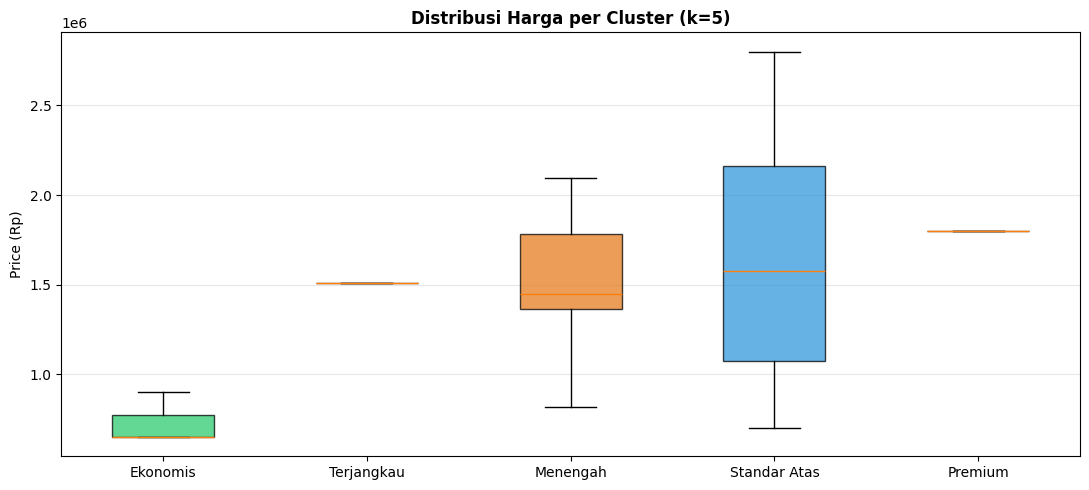

In [17]:
seg_order = ['Ekonomis', 'Terjangkau', 'Menengah', 'Standar Atas', 'Premium']
palette   = ['#2ecc71', '#f1c40f', '#e67e22', '#3498db', '#e74c3c']

plt.figure(figsize=(11, 5))
data_plot = [df[df['segmen'] == s]['price'].values for s in seg_order]
bp = plt.boxplot(data_plot, patch_artist=True, tick_labels=seg_order)
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
plt.title(f'Distribusi Harga per Cluster (k={K_OPTIMAL})', fontweight='bold')
plt.ylabel('Price (Rp)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3 Validasi Visual PCA 2D

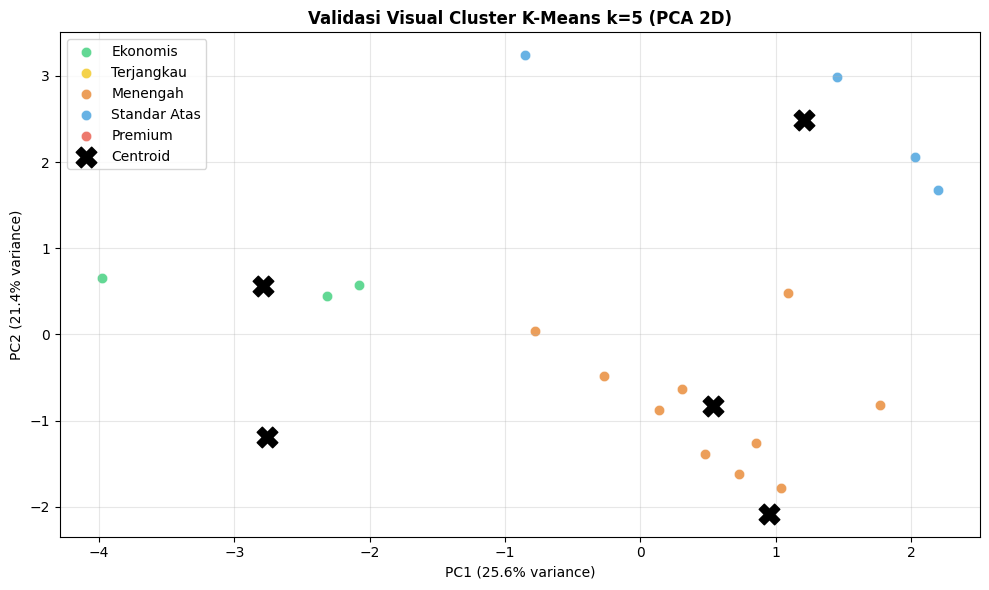

Total variance explained PC1+PC2: 47.0%


In [18]:
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
for seg, col in zip(seg_order, palette):
    mask = df['segmen'] == seg
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=col, label=seg, alpha=0.75, s=55,
        edgecolors='white', linewidths=0.4
    )

centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    c='black', marker='X', s=220, label='Centroid', zorder=5
)

var = pca.explained_variance_ratio_ * 100
plt.xlabel(f'PC1 ({var[0]:.1f}% variance)')
plt.ylabel(f'PC2 ({var[1]:.1f}% variance)')
plt.title(f'Validasi Visual Cluster K-Means k={K_OPTIMAL} (PCA 2D)', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Total variance explained PC1+PC2: {sum(var):.1f}%')

### 5.4 Silhouette Score per Sampel

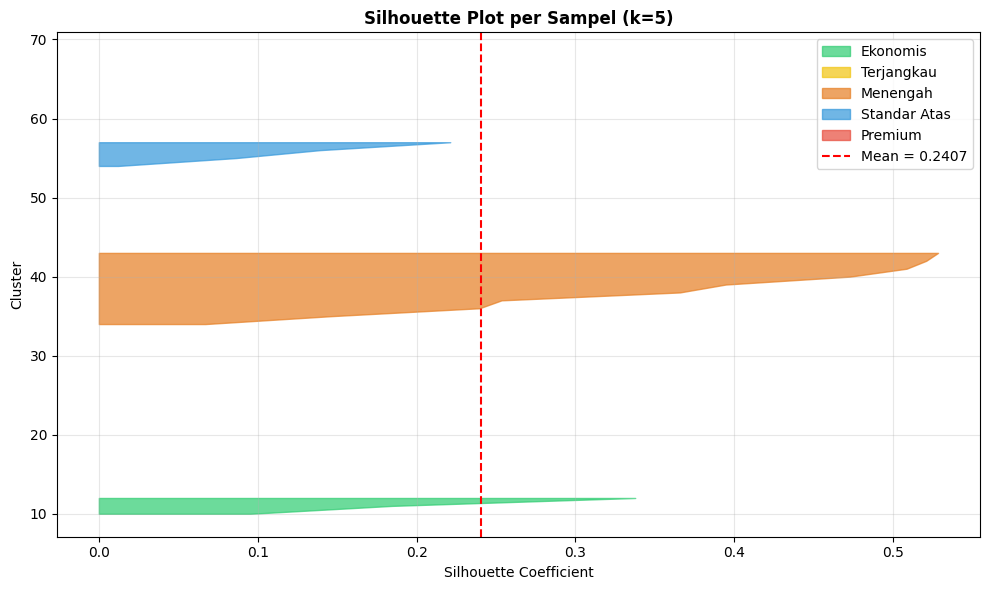

In [19]:
from sklearn.metrics import silhouette_samples

sil_samples = silhouette_samples(X_scaled, kmeans.labels_)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for i, (seg, col) in enumerate(zip(seg_order, palette)):
    cluster_id  = cluster_stats[cluster_stats['segmen'] == seg]['cluster'].values[0]
    sil_cluster = np.sort(sil_samples[kmeans.labels_ == cluster_id])
    size        = sil_cluster.shape[0]
    y_upper     = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_cluster, alpha=0.7, color=col, label=seg)
    y_lower = y_upper + 10

ax.axvline(x=sil, color='red', linestyle='--', linewidth=1.5, label=f'Mean = {sil:.4f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Plot per Sampel (k={K_OPTIMAL})', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5 Rata-rata Fitur per Cluster (Bar Chart)

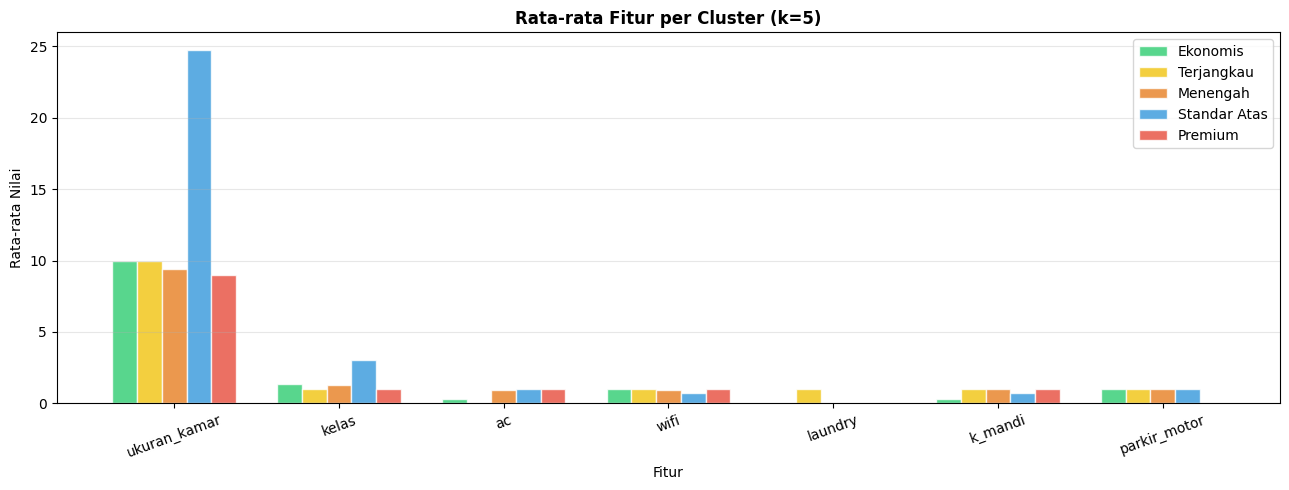

In [20]:
fitur_tampil = ['ukuran_kamar', 'kelas', 'ac', 'wifi', 'laundry', 'k_mandi', 'parkir_motor']
cluster_mean = df.groupby('segmen')[fitur_tampil].mean().loc[seg_order]

x     = np.arange(len(fitur_tampil))
width = 0.15

fig, ax = plt.subplots(figsize=(13, 5))
for i, (seg, col) in enumerate(zip(seg_order, palette)):
    ax.bar(x + i * width, cluster_mean.loc[seg], width, label=seg, color=col, alpha=0.8, edgecolor='white')

ax.set_xlabel('Fitur')
ax.set_ylabel('Rata-rata Nilai')
ax.set_title(f'Rata-rata Fitur per Cluster (k={K_OPTIMAL})', fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(fitur_tampil, rotation=20)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Save Model

In [21]:
PKL_OUTPUT = 'model_kmeans_kost_k5.pkl'

package = {
    'model'             : kmeans,
    'scaler'            : scaler,
    'feature_cols'      : NUMERIC_FEATS,
    'cluster_to_segmen' : cluster_to_segmen,
    'cluster_stats'     : cluster_stats,
    'df_clustered'      : df,
    'metrics'           : {
        'silhouette'        : sil,
        'davies_bouldin'    : db,
        'calinski_harabasz' : ch,
        'inertia'           : kmeans.inertia_,
        'k'                 : K_OPTIMAL
    }
}

with open(PKL_OUTPUT, 'wb') as f:
    pickle.dump(package, f)

print(f'Model disimpan ke: {PKL_OUTPUT}')
print(f'Isi package: {list(package.keys())}')

Model disimpan ke: model_kmeans_kost_k5.pkl
Isi package: ['model', 'scaler', 'feature_cols', 'cluster_to_segmen', 'cluster_stats', 'df_clustered', 'metrics']


## 7. Sistem Rekomendasi

In [ ]:
with open(PKL_OUTPUT, 'rb') as f:
    loaded = pickle.load(f)

model_loaded  = loaded['model']
scaler_loaded = loaded['scaler']
df_db         = loaded['df_clustered']
c2s           = loaded['cluster_to_segmen']
stats         = loaded['cluster_stats']

print('Model berhasil di-load dari PKL')
print('\nSegmen tersedia:')
for _, row in stats.iterrows():
    print(f"  {row['segmen']:15s} -> Rp {row['price_mean']/1e6:.2f}jt/bln  "
          f"(Rp {row['price_min']/1e6:.1f}jt - Rp {row['price_max']/1e6:.1f}jt)")

In [ ]:
def rekomendasi_kost(budget, top_n=10):
    stats_sorted            = stats.copy()
    stats_sorted['selisih'] = (stats_sorted['price_mean'] - budget).abs()
    best_cluster            = stats_sorted.sort_values('selisih').iloc[0]['cluster']
    best_segmen             = c2s[best_cluster]

    kost_cluster                  = df_db[df_db['cluster'] == best_cluster].copy()
    kost_cluster['selisih_harga'] = (kost_cluster['price'] - budget).abs()
    kost_cluster['kecocokan_pct'] = kost_cluster['selisih_harga'].apply(
        lambda s: max(0, round(100 - (s / budget * 100), 1))
    )
    kost_cluster = kost_cluster.sort_values('kecocokan_pct', ascending=False)

    cols   = ['nama', 'wilayah', 'lokasi', 'kelas', 'ac', 'wifi', 'k_mandi', 'ukuran_kamar', 'tipe_kos', 'price', 'kecocokan_pct']
    result = kost_cluster[cols].head(top_n).reset_index(drop=True)
    result.index += 1

    print(f'Budget       : Rp {budget:,.0f}')
    print(f'Segmen cocok : {best_segmen}')
    print(f'Total kost   : {len(kost_cluster)}')
    return result

In [ ]:
BUDGET_USER = 1_500_000

hasil = rekomendasi_kost(BUDGET_USER, top_n=10)

label_kelas = {1: 'Ekonomi', 2: 'Standar', 3: 'Premium'}
label_tipe  = {1: 'Pria',    2: 'Wanita',  3: 'Campur'}

tampil                  = hasil.copy()
tampil['kelas']         = tampil['kelas'].map(label_kelas)
tampil['tipe_kos']      = tampil['tipe_kos'].map(label_tipe)
tampil['ac']            = tampil['ac'].apply(lambda x: 'Ada' if x else 'Tidak')
tampil['wifi']          = tampil['wifi'].apply(lambda x: 'Ada' if x else 'Tidak')
tampil['k_mandi']       = tampil['k_mandi'].apply(lambda x: 'Dalam' if x else 'Luar')
tampil['price']         = tampil['price'].apply(lambda x: f'Rp {x:,.0f}')
tampil['kecocokan_pct'] = tampil['kecocokan_pct'].apply(lambda x: f'{x:.1f}%')
tampil.columns          = ['Nama', 'Wilayah', 'Lokasi', 'Kelas', 'AC', 'Wifi', 'K. Mandi', 'Ukuran (m2)', 'Tipe', 'Harga/Bln', 'Kecocokan']
tampil

In [ ]:
vis               = hasil.head(10).copy()
vis['label_nama'] = vis['nama'].str[:30] + '...'

plt.figure(figsize=(11, 6))
bars = plt.barh(
    vis['label_nama'],
    vis['kecocokan_pct'],
    color=plt.cm.RdYlGn(vis['kecocokan_pct'] / 100),
    edgecolor='white'
)
for bar, pct, price in zip(bars, vis['kecocokan_pct'], vis['price']):
    plt.text(
        bar.get_width() - 1,
        bar.get_y() + bar.get_height() / 2,
        f'{pct:.1f}% | Rp {price/1e6:.2f}jt',
        va='center', ha='right', fontsize=9, fontweight='bold'
    )
plt.xlabel('Kecocokan Harga (%)')
plt.title(f'Rekomendasi Kost - Budget Rp {BUDGET_USER:,.0f} (k={K_OPTIMAL})', fontweight='bold')
plt.xlim(0, 115)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()